Exercise 3 - Gradient Descent function

Exercise 4 - Linear Regression

a. Read in the dataset. When reading in the data use the option na values=’?’. Then drop all NaN values using dropna().

In [14]:
#load in the libaries needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [10]:
#read in the csv
df = pd.read_csv('/Users/naomiliftman/Desktop/MSDS/Data 558/Auto.csv', na_values = "?")
#drop the nas
df.dropna()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


b. Use the OLS function from the statsmodels package to perform a simple linear re-
gression with mpg as the response and weight as the predictor. Be sure to include an
intercept. Use the summary() attribute to print the results. Comment on the output.
For example:
(i) Is there a relationship between the predictor and the response?
(ii) How strong is the relationship between the predictor and the response?
(iii) Is the relationship between the predictor and the response positive or negative?

In [20]:
#start by making our own data frame with the predictor and intercept
X = pd.DataFrame({'intercept': np.ones(df.shape[0]),
                  'weight': df['weight']})
X[:5]

,intercept,weight
0,1.0,3504
1,1.0,3693
2,1.0,3436
3,1.0,3433
4,1.0,3449


In [23]:
#pull out the variable that will be our response
y = df['mpg']
#create the model and fit it
model = sm.OLS(y, X)
results = model.fit()
#summary attribute
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     886.6
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          5.37e-103
Time:                        13:06:59   Log-Likelihood:                -1146.0
No. Observations:                 397   AIC:                             2296.
Df Residuals:                     395   BIC:                             2304.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     46.3174      0.796     58.166      0.0

We can see that our model's weight coefficient has a p-value that is less than our alpha level of 0.05 which means that we have statistically significant evidence to suggest there is a relationship between the weight of a car and it's miles per gallon. Looking at the coefficient on our weight variable we can see that our model predicts a decrease of 0.0077 miles per gallon for every single lb increase in the weight of our car. While the actual change in mpg is small, due to the small p-value we know that this is still strong.

c. Plot the response and the predictor using the plot fit function

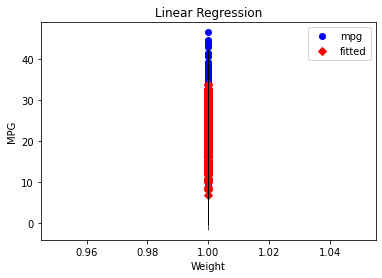

In [26]:
fig, ax = plt.subplots()
fig = sm.graphics.plot_fit(results, 0, ax=ax)
ax.set_ylabel("MPG")
ax.set_xlabel("Weight")
ax.set_title("Linear Regression")
plt.show()